# Analiza rezultatov z IMO
V tem zvezku analiziramo rezultate Mednarodne matematične olimpijade, podatki so shranjeni v dveh CSV datotekah:
- "rezultati.csv" - podatki o rezultatih tekmovalcev na IMO
- "memo.csv" - podatki o tekmovalcih vsake države na MEMO

V zvezku pogledam0:

1. najbolljše države in tekmovalce
2. zmagovalne države
3. rezultate gostiteljev
4. leto pridružitve držav
5. uvrstitve Slovenije
6. razlike v težavnosti nalog
7. MEMO tekmovalce na IMO

Najprej uvozimo potrebne knjižnice in CSV datoteko.

In [690]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("rezultati.csv")

### 1. Najboljše države in tekmovalci
Poglejmo si 20 najuspešnejših držav in 20 najuspešnejših tekmovalcev v zgodovini IMO.

In [772]:
from IPython.display import display, HTML

df["Oseba"] = df["Ime"] + " " + df["Priimek"]

udelezbe_osebe = df.groupby("Oseba").size()
medalje_osebe = pd.crosstab(df["Oseba"], df["Medalja"])[["G", "S", "B", "HM"]]
medalje_osebe["Udeležbe"] = udelezbe_osebe
medalje_drzave = pd.crosstab(df["Država"], df["Medalja"])[["G", "S", "B", "HM"]]


tabela_osebe = medalje_osebe.sort_values(by=["G", "S", "B", "HM"], ascending=False).head(20)
tabela_drzave = medalje_drzave.sort_values(by=["G", "S", "B", "HM"], ascending=False).head(20)

def olepsaj(tabela, naslov):
    return (
        tabela.style
        .set_caption(naslov)
        .format(precision=0)
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "16px"), ("font-weight", "bold"), ("padding", "8px")]},
            {"selector": "th", "props": [("background-color", "#f0dcc8"), ("color", "#281706"), ("padding", "8px 12px")]},
            {"selector": "td", "props": [("padding", "6px 12px"), ("text-align", "center"), ("background-color", "#a25c0c")]}
        ])
        .to_html()
    )

display(HTML(
    '<div style="display: flex; gap: 100px;">'
    f'<div>{olepsaj(tabela_drzave, "Top 20 po državah")}</div>'
    f'<div>{olepsaj(tabela_osebe, "Top 20 po osebah")}</div>'
    '</div>'
))

Medalja,G,S,B,HM
Država,,,,
People's Republic of China,197,37,6,0
United States of America,160,122,31,1
Russian Federation,110,64,12,0
Republic of Korea,102,87,28,8
Hungary,91,178,121,14
Romania,89,164,114,13
Union of Soviet Socialist Republics,77,67,45,2
Vietnam,73,123,87,3
United Kingdom,61,126,136,18


Kot pričakovano so na prvih mestih med državami matematične velesile, na seznamu pa lahko opazimo tudi nekdanjo državo Sovjetsko zvezo, ki je še danes na 7. mestu po uspešnosti, kljub temu da ne obstaja že 35 let.

### 2. Zmagovalne države
Zdaj želimo ugotoviti, kolikokrat je katera država dosegla prvo mesto na IMO. Pričakujemo, da bodo med državami z največ zmagami države z vrha seznama uspešnosti. Zaradi zgodovinskih razlogov bomo Rusijo in Sovjetsko zvezo obravnavali kot eno državo.

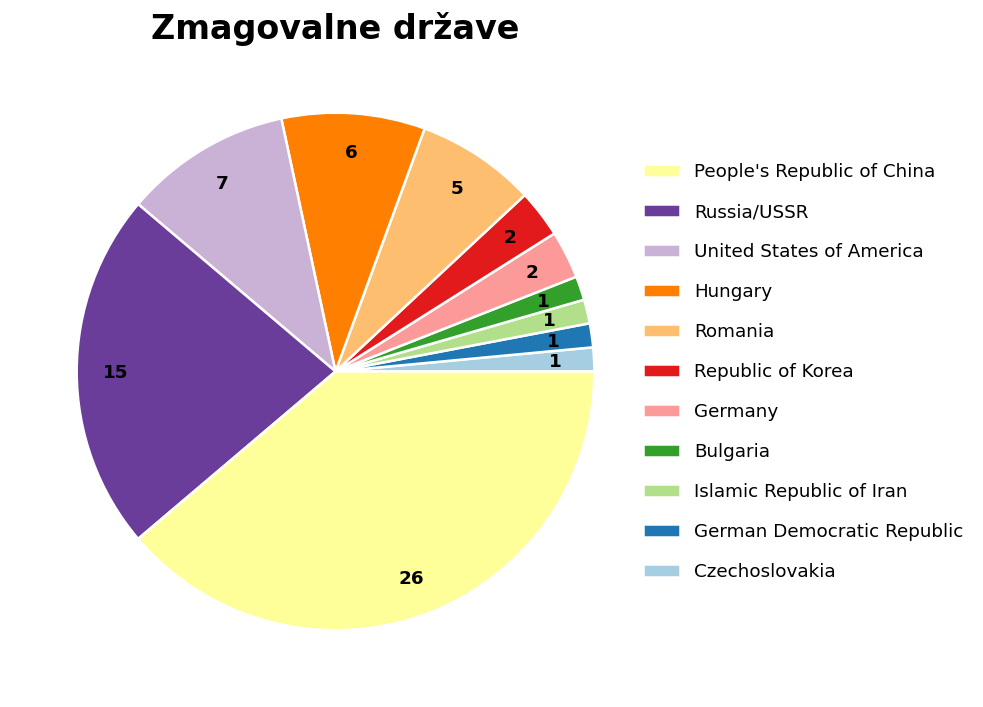

In [773]:
from collections import defaultdict

preimenovanje = {"Russian Federation": "Russia/USSR", "Union of Soviet Socialist Republics": "Russia/USSR"}

df_all = df.copy()
df_all["Država skupina"] = df_all["Država"].replace(preimenovanje)
df_all["Skupno"] = pd.to_numeric(df_all["Skupno"], errors="coerce").fillna(0)

tocke_po_letih = df_all.groupby(["Leto", "Država skupina"])["Skupno"].sum().reset_index()

zmage = defaultdict(int)
for leto, skupina in tocke_po_letih.groupby("Leto"):
    skupina_je = skupina[skupina["Skupno"] > 0]
    if not skupina_je.empty:
        zmage[skupina_je.loc[skupina_je["Skupno"].idxmax(), "Država skupina"]] += 1

labels, velikosti = zip(*sorted(zmage.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(9, 6), dpi=120)
wedges, _, _ = ax.pie(
    velikosti,
    autopct=lambda pct: f"{round(pct/100 * sum(velikosti))}",
    colors=plt.cm.Paired.colors,
    pctdistance=0.85,
    textprops={"fontsize": 11, "color": "black", "weight": "bold"},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

ax.legend(wedges[::-1], labels[::-1], labelspacing=1.2, loc="center left", bbox_to_anchor=(0.95, 0.5), fontsize=11, frameon=False)
ax.set_title("Zmagovalne države", fontsize=20, weight="bold")
plt.tight_layout()
plt.show()

Kot vidimo, res tudi po številu zmag vodi Kitajska, zanimivo pa je, da je kljub 67 izvedbam tekmovanja olimpijado zmagalo le 11 različnih držav.

### 3. Rezultati gostiteljice
V tem delu bomo pogledali ali država gostiteljica doma doseže boljše rezultate kot navadno. Pogledamo, v katerem procentu najboljših držav je bila država v vseh svojih letih sodelovanja in leta, ko je bila gostiteljica, ter vzamemo razliko med tema podatkoma. Domnevamo, da olimpijada na domačem terenu tekmovalcem vlije dodatne samozavesti in niso utrujeni od potovanja, zato dosegajo boljše rezultate.

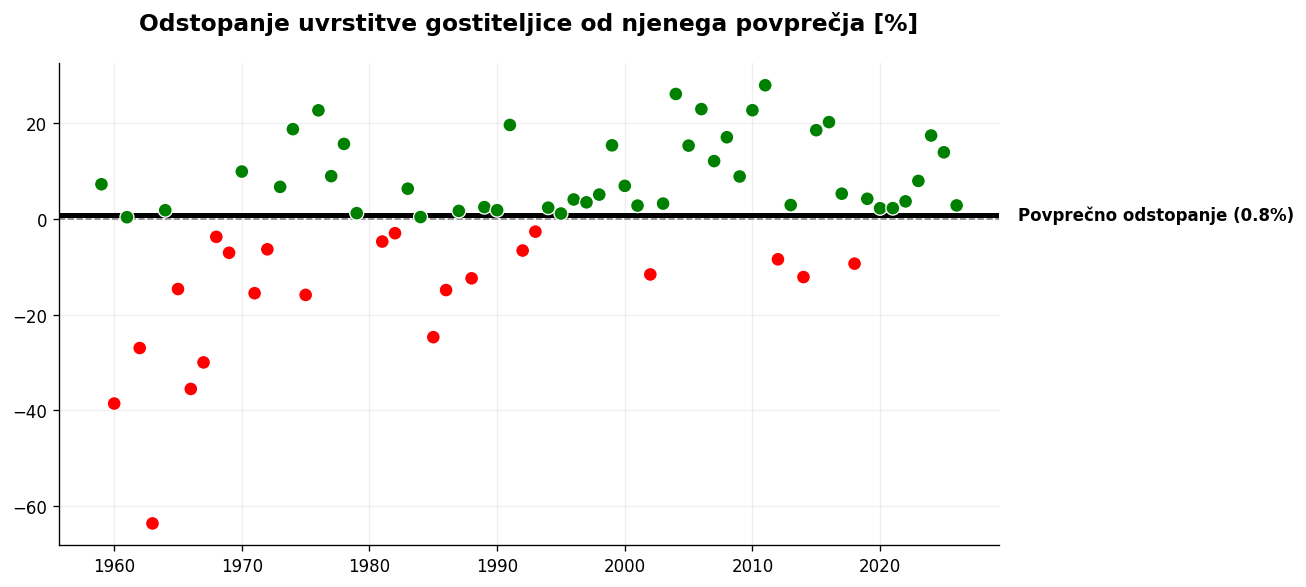

In [774]:
povp_mesto = df.groupby(["Leto", "Država"])["Mesto"].mean().reset_index(name="Povprečno mesto")
povp_mesto["Relativna uvrstitev"] = povp_mesto.groupby("Leto")["Povprečno mesto"].rank(method="min", pct=True) * 100

povp_relativna = povp_mesto.groupby("Država")["Relativna uvrstitev"].mean().rename("Povprečna relativna uvrstitev")

gostitelji = df[["Leto", "Gostiteljica"]].drop_duplicates("Leto").rename(columns={"Gostiteljica": "Država"})

g = gostitelji.merge(povp_mesto, on=["Leto", "Država"], how="left").merge(povp_relativna, on="Država", how="left")
g["Odstopanje"] = g["Povprečna relativna uvrstitev"] - g["Relativna uvrstitev"]
g = g.sort_values("Leto")

povprecje = g["Odstopanje"].mean()
barve = ["green" if v > 0 else "red" if v < 0 else "yellow" for v in g["Odstopanje"]]

plt.figure(figsize=(11, 5), dpi=120)
plt.scatter(g["Leto"], g["Odstopanje"], c=barve, s=70, edgecolor="white", linewidth=0.8, zorder=3)
plt.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=1)
plt.axhline(povprecje, color="black", linewidth=3, zorder=2)
plt.text(1.02, 0.675, f"Povprečno odstopanje ({povprecje:.1f}%)", transform=plt.gca().transAxes, fontsize=10, weight="bold")

plt.title("Odstopanje uvrstitve gostiteljice od njenega povprečja [%]", fontsize=14, weight="bold", pad=20)
plt.grid(True, alpha=0.2)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Kot vidimo so nekateri tekovalci tekmovali bolje kot ponavadi, nekateri pa slabše. Povprečno odstopanje pa je 0,8 % kar pomeni, da je vpliv domačega terena na IMO zanemarljiv in je naša hipoteza napačna.

### 4. Prvo leto sodelovanja
Pogledali bomo katerega leta so se IMO pridružile države, ki so bile na olimpijadi leta 2026.

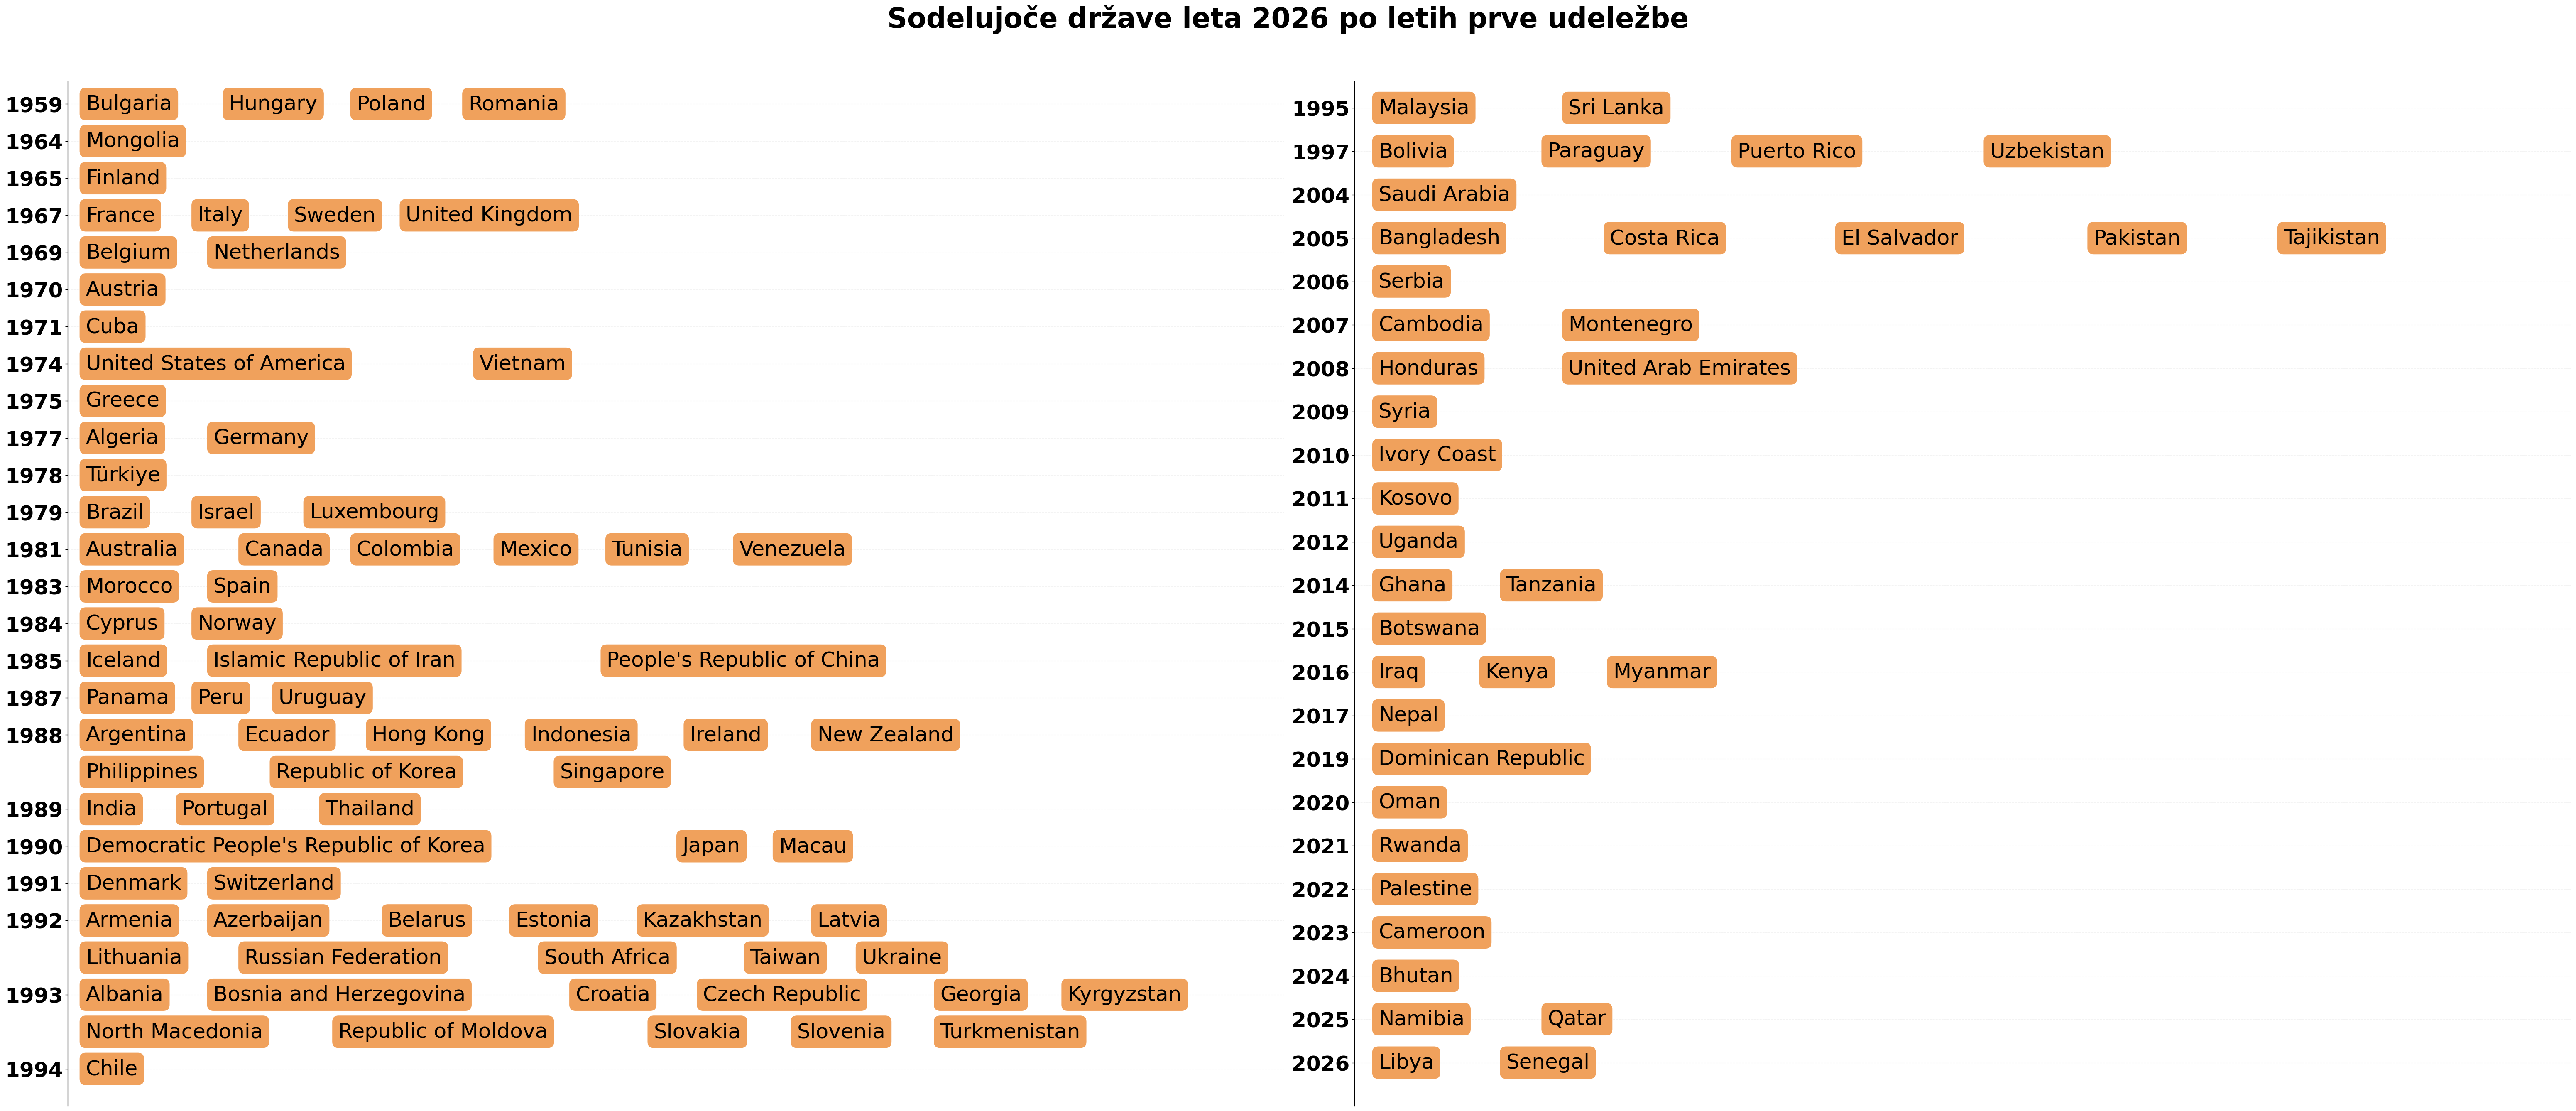

In [775]:
drzave_2026 = df[df["Leto"] == 2026]["Država"].unique()
rezultat = df.groupby("Država")["Leto"].min().reset_index(name="Prva udeležba")
rezultat = rezultat[rezultat["Država"].isin(drzave_2026)]

sirina_na_znak, presledek, max_na_vrstico, razmik_vrstic = 1.3, 1.5, 6, 1.6

def izracunaj_pozicije(drzave):
    pozicije = [1]
    for d in drzave[:-1]:
        pozicije.append(pozicije[-1] + len(d) * sirina_na_znak + presledek)
    return pozicije

def sirina(drzave):
    return izracunaj_pozicije(drzave)[-1] + len(drzave[-1]) * sirina_na_znak if drzave else 0

leta_bloki = []
for leto, skupina in rezultat.groupby("Prva udeležba"):
    drzave = sorted(skupina["Država"])
    podvrstice = [drzave[i:i + max_na_vrstico] for i in range(0, len(drzave), max_na_vrstico)]
    leta_bloki.append([{"leto": leto, "drzave": p, "prikazi": idx == 0} for idx, p in enumerate(podvrstice)])

leta_bloki.sort(key=lambda blok: blok[0]["leto"])
polovica = (len(leta_bloki) + 1) // 2
polovice = [[v for blok in leta_bloki[:polovica] for v in blok], [v for blok in leta_bloki[polovica:] for v in blok]]
sirine = [max((sirina(v["drzave"]) for v in del_skupine), default=0) for del_skupine in polovice]

fig, axes = plt.subplots(1, 2, figsize=(max(sirine) * 0.5 + 4, max(len(p) for p in polovice) * 0.5 * razmik_vrstic), dpi=120)

for ax, del_skupine, sirina_dela in zip(axes, polovice, sirine):
    yticks_pozicije, yticks_oznake = [], []
    for pozicija, vrstica in enumerate(del_skupine):
        y = pozicija * razmik_vrstic
        for x, drzava in zip(izracunaj_pozicije(vrstica["drzave"]), vrstica["drzave"]):
            ax.text(x, y, drzava, ha="left", va="center", fontsize=30,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0a15c", edgecolor="none"))
        if vrstica["prikazi"]:
            yticks_pozicije.append(y)
            yticks_oznake.append(vrstica["leto"])

    ax.set_ylim(-1, len(del_skupine) * razmik_vrstic)
    ax.set_xlim(-0.5, sirina_dela + 5)
    ax.set_yticks(yticks_pozicije)
    ax.set_yticklabels(yticks_oznake, fontsize=30, weight="bold")
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.grid(axis="y", alpha=0.15, linestyle="--")
    for spine in ["top", "right", "bottom"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Sodelujoče države leta 2026 po letih prve udeležbe", fontsize=40, weight="bold", y=1.03)
plt.tight_layout()
plt.show()

Vidimo lahko, da se Bolgarija, Madžarska, Poljska in Romunija tekmovanja udeležujejo že od samega začetka leta 1959, Slovenija se mu je pridržila leta 1993, zadnji pa sta se leta 2026 pridružili Libija in Senegal.

### 5. Uspešnost slovenije
Zanima nas ralativna uvrstitev slovenske ekipe skozi leta njenega sodelovanja.

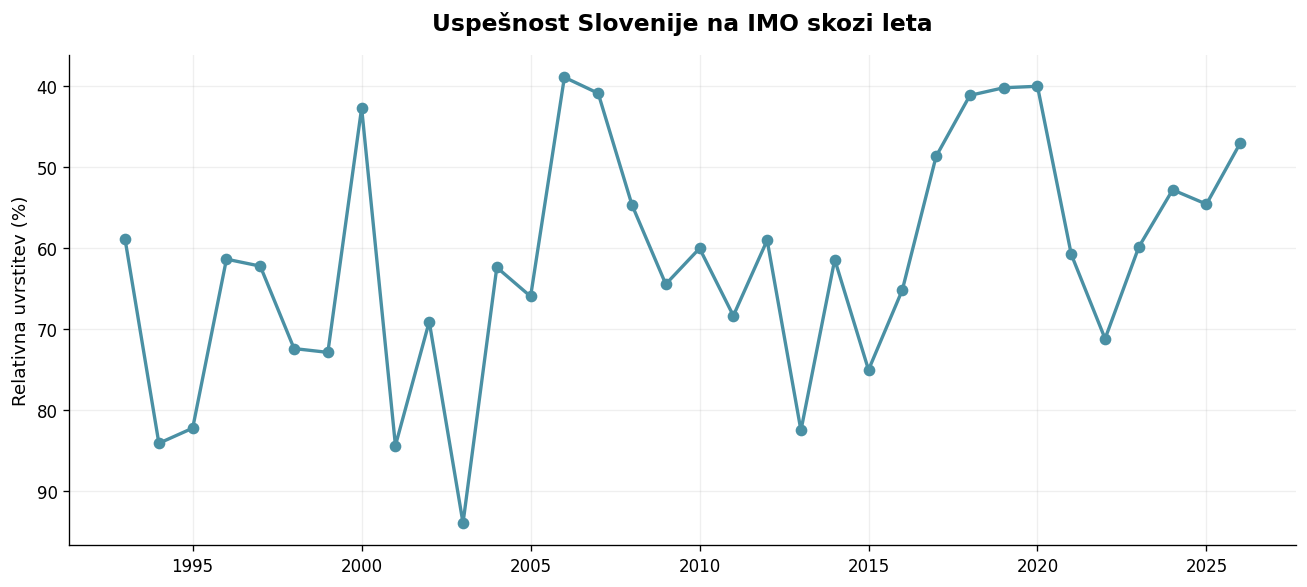

In [776]:
slovenija = povp_mesto[povp_mesto["Država"] == "Slovenia"].sort_values("Leto")

plt.figure(figsize=(11, 5), dpi=120)
plt.plot(slovenija["Leto"], slovenija["Relativna uvrstitev"], marker="o", color="#4a90a4", linewidth=2)
plt.gca().invert_yaxis()
plt.ylabel("Relativna uvrstitev (%)", fontsize=11)
plt.title("Uspešnost Slovenije na IMO skozi leta", fontsize=14, weight="bold", pad=15)
plt.grid(True, alpha=0.2)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Kot vidimo je Slovenija večino časa med 60 in 70 odstotkov najboljših držav. Najmanj uspešna je bila leta 2003, najuspešnejša pa leta 2006 ko je bila gostiteljica.

### 6. Težavnost nalog
Pogledali bomo odvisnost uvrstitve tekmovalcev od števila točk na posamezni nalogi od leta 2000 naprej. Seveda ob večjem številu točk pričakujemo višjo uvrstitev in zato pozitivno korelacijo.

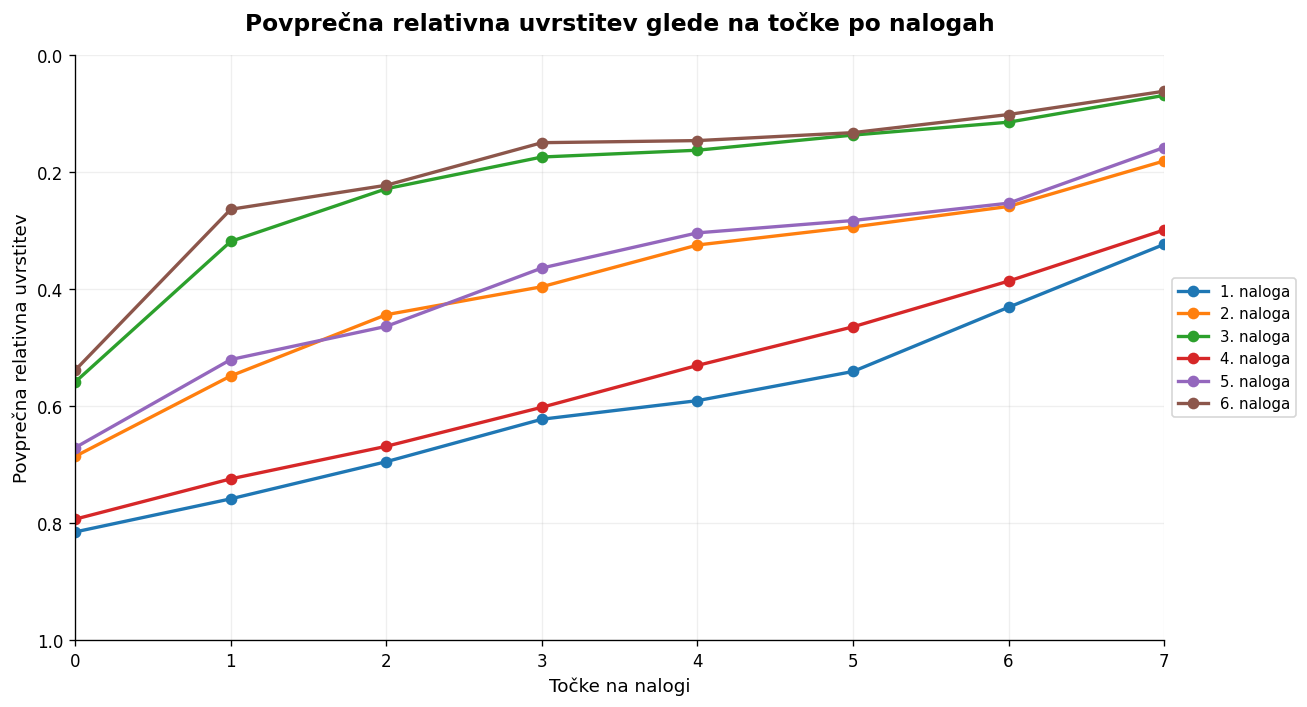

In [777]:
import ast

df_delo = df.copy()
df_delo = df_delo[df_delo["Leto"] >= 2000]
df_delo["Točke"] = df_delo["Točke"].apply(ast.literal_eval)

df_brez_pomankljivih = df_delo[df_delo["Točke"].apply(lambda t: isinstance(t, list) and len(t) == 6 and None not in t)].copy()

stevilo_tekmovalcev = df_brez_pomankljivih.groupby("Leto")["Mesto"].transform("count")
df_brez_pomankljivih["Relativna uvrstitev"] = df_brez_pomankljivih["Mesto"] / stevilo_tekmovalcev

tocke_df = pd.DataFrame(
    df_brez_pomankljivih["Točke"].tolist(),
    columns=[f"{i+1}. naloga" for i in range(6)],
    index=df_brez_pomankljivih.index
)
df_nal = pd.concat([df_brez_pomankljivih[["Relativna uvrstitev"]], tocke_df], axis=1)

barve = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)
for i in range(6):
    stolpec = f"{i+1}. naloga"
    df_nal[stolpec] = pd.to_numeric(df_nal[stolpec], errors="coerce")

    povprecja = df_nal.groupby(stolpec)["Relativna uvrstitev"].mean().reset_index()

    ax.plot(
        povprecja[stolpec],
        povprecja["Relativna uvrstitev"],
        marker="o",
        color=barve[i],
        label=f"{i+1}. naloga",
        linewidth=2
    )

ax.invert_yaxis()
ax.set_ylim(1, 0)
ax.set_xlim(0, 7)
ax.set_xlabel("Točke na nalogi", fontsize=11)
ax.set_ylabel("Povprečna relativna uvrstitev", fontsize=11)
ax.set_title("Povprečna relativna uvrstitev glede na točke po nalogah", fontsize=14, weight="bold", pad=15)
ax.legend(fontsize=9, frameon=True, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(True, alpha=0.2)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

Kot vidimo se s številom točk res viša povprečna uvrstitev za vsako izmed nalog. Prav tako vidimo, da so naloge vertikalno razporejene, kar nam pove o njihovi težavnosti. 1. in 4. naloga sta najlažji, sledita jima 2. in 5. naloga, najtežji pa sta 3. in 6. naloga, kar je v skladu z znanimi dejstvi o težavnosti nalog na IMO.

### 7. MEMO primerjava
Iz CSV datoteke uvozimo še podatke o predstavnikih vsake države na Srednjeevropski matematični olimpijadi (MEMO). Zanima nas, kolikšnemu deležu MEMO tekmovalcev iz vsake države se je uspelo uvrstiti tudi na IMO.

C:\Users\nace\AppData\Local\Temp\ipykernel_4984\3563291495.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(primerjava["Država"], rotation=45, ha="right")


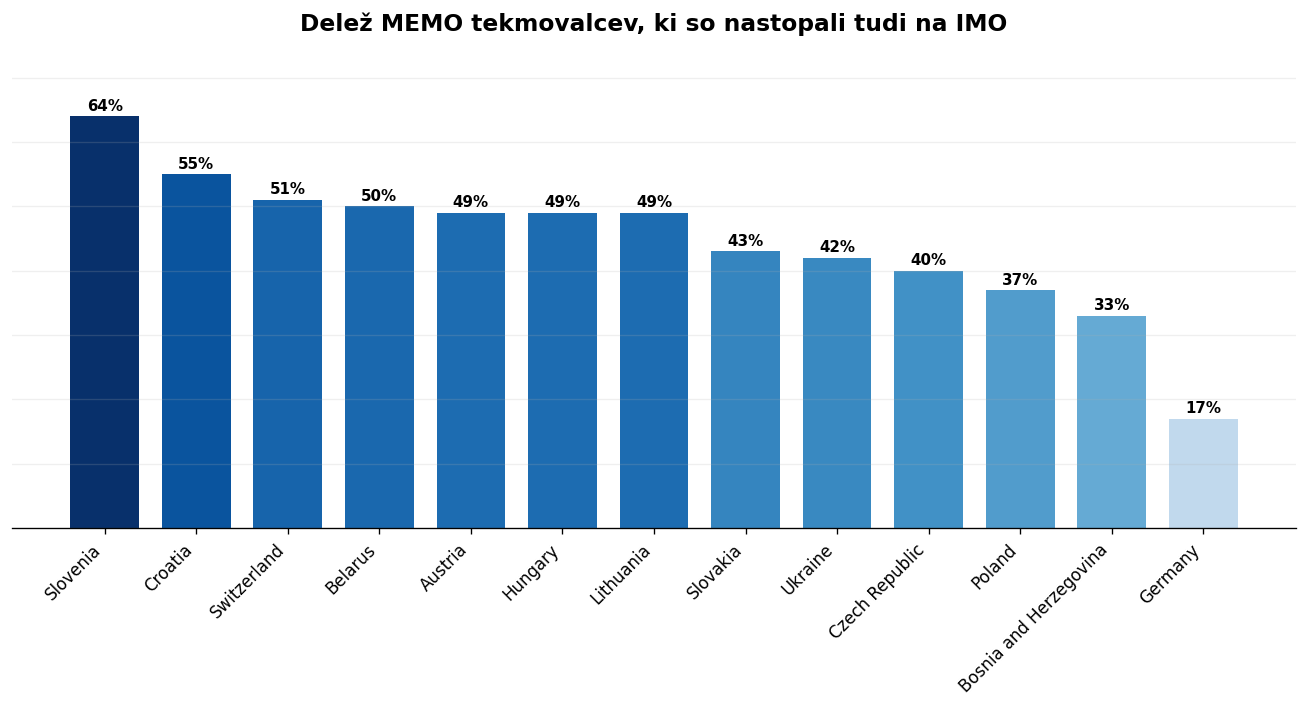

In [778]:
df_memo = pd.read_csv("memo.csv")
df_memo["Država"] = df_memo["Država"].replace({"Czechia": "Czech Republic"})

memo = df_memo.groupby("Država")["Tekmovalec"].apply(set)
imo = df.groupby("Država")["Oseba"].apply(set)

primerjava = pd.DataFrame({
    "Država": memo.index,
    "Delež": [round(len(memo[d] & imo.get(d, set())) / len(memo[d]) * 100, 0) for d in memo.index]
}).sort_values("Delež", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6), dpi=120)

barve = plt.cm.Blues(primerjava["Delež"] / primerjava["Delež"].max())
stolpci = ax.bar(primerjava["Država"], primerjava["Delež"], width=0.75, color=barve)

for stolpec, vrednost in zip(stolpci, primerjava["Delež"]):
    ax.text(stolpec.get_x() + stolpec.get_width() / 2, vrednost + 1, f"{vrednost:.0f}%", ha="center", fontsize=9, weight="bold")

ax.set_title("Delež MEMO tekmovalcev, ki so nastopali tudi na IMO", fontsize=14, weight="bold", pad=15)
ax.set_xticklabels(primerjava["Država"], rotation=45, ha="right")
ax.tick_params(axis="y", left=False, labelleft=False)
ax.set_ylim(0, primerjava["Delež"].max() * 1.15)
ax.grid(axis="y", alpha=0.2)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Kot vidimo je na prvem mestu s 64 % Slovenija, kar ni presenetljivo, saj je v preteklosti Slovenija na MEMO in IMO pošiljala isto ekipo. Na zadnjem mestu pa je Nemčija s 17 %, kar je prav tako pričakovano zaradi njenega velikega števila prebivalstva in večje konkurence.

### Zaključek
V zvezku smo pogledali številna zanimiva dejstva o rezultatih z IMO, projekt bi lahko smiselno razširili tako, da bi pridobili podatke še z večih matematičnih olimpijad in primerjali rezultate istih tekmovalcev in številne trende, ki se pojavljajo.